In [1]:
import sys
sys.path.append("../src")

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from data_utils import gen_circle, splines

In [2]:
fname = "../tmp/orbits/horizons_results.txt"
data = splines.load_horizons(fname)

In [3]:
x_rep, y_rep, z_rep = splines.find_periodicity(data)

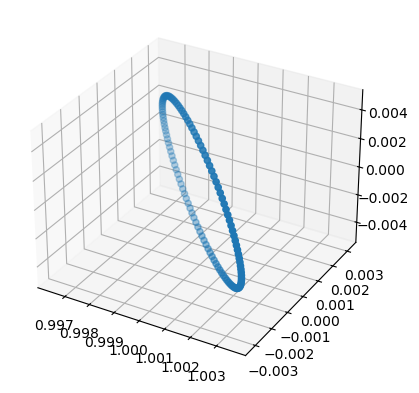

In [4]:
norm_data = splines.normalize_data(data, LU = 384400, TU = 4.342479883700495, center = [1, 0, 0])
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(norm_data[:117,1], norm_data[:117,2], norm_data[:117,3])

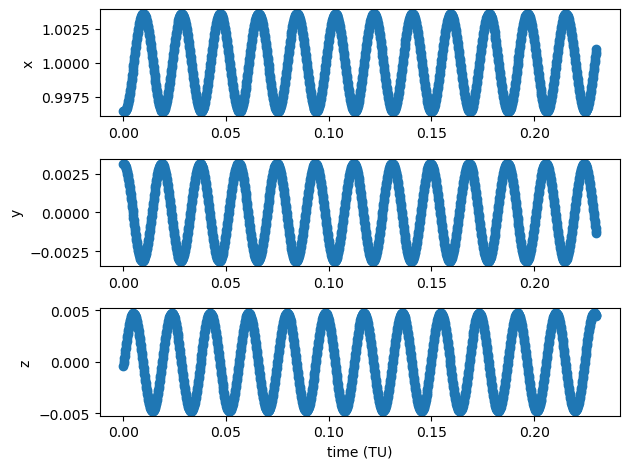

In [5]:
fig, ax = splines.plot_components(norm_data)

In [6]:
cleaned_data = norm_data[:117, :]
bspl = splines.make_spline(cleaned_data)


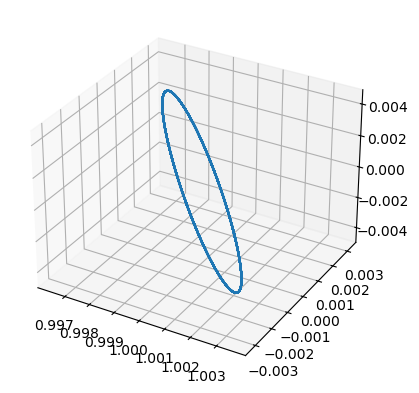

In [7]:
ax = plt.axes(projection='3d')
xx = np.linspace(0, 12 *(cleaned_data[-1, 0] + cleaned_data[1,0]) , 1000)
ax.plot3D(bspl(xx)[:,0], bspl(xx)[:,1], bspl(xx)[:,2])

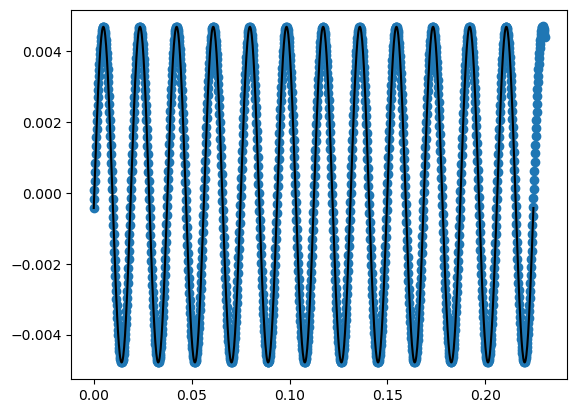

In [8]:
fig = plt.figure()
plt.plot(xx, bspl(xx)[:, 2], color="black")
plt.scatter(norm_data[:, 0], norm_data[:,3])